# GPT-2 Attention Weight Analyser  
Adapted from Mike X Cohen (LLM course).

## Attention sinks?

This is the **attention sink** phenomenon; e.g. the first word in a sentence (Xiao et al., 2023).  
Softmax forces all weights to sum to 1 — when no token is strongly relevant,
the model dumps spare attention mass on token 0, which is the only position
reachable by *every* token due to causal masking. It is learned during training
and is largely **uninformative about meaning**.

**Fix:** set `mask_sink=True` — this zeros out token 0 and re-normalises the
remaining weights so they still sum to 1, revealing the genuine semantic signal.

## Which layers to use?

| Layer range | Role |
|---|---|
| 0–2 | Local syntax, positional proximity |
| 3–8 | Semantic relationships, coreference |
| **9–11** | **Most relevant — directly drives the output logits** |

Default: average layers 9–11, all heads, with sink masking on.

In [2]:
!pip install torchinfo -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

In [3]:
model_name = "gpt2"
gpt2      = GPT2LMHeadModel.from_pretrained(model_name, output_attentions=True)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
gpt2.eval()
print(f"Loaded {model_name}: {gpt2.config.n_layer} layers, {gpt2.config.n_head} heads")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded gpt2: 12 layers, 12 heads


## Helpers

In [4]:
def apply_sink_mask(weights):
    """
    Remove the attention-sink effect by zeroing token 0 and
    re-normalising remaining weights to sum to 1.
    Works on a 1-D array (last-token row) or 2-D matrix.
    """
    w = weights.copy()
    if w.ndim == 1:
        w[0] = 0.0
        total = w.sum()
        return w / total if total > 0 else w
    else:   # 2-D matrix
        w[:, 0] = 0.0
        totals = w.sum(axis=1, keepdims=True)
        return np.where(totals > 0, w / totals, w)


def attention_rollout(attentions):
    """
    Attention rollout (Abnar & Zuidema, 2020).
    Propagates attention through residual connections across all layers.
    attentions : tuple of tensors [1, n_heads, seq, seq]
    Returns    : np.ndarray [seq, seq]
    """
    rollout = torch.eye(attentions[0].shape[-1])
    for layer_attn in attentions:
        avg = layer_attn[0].mean(dim=0)
        aug = avg + torch.eye(avg.shape[0])
        aug = aug / aug.sum(dim=-1, keepdim=True)
        rollout = aug @ rollout
    return rollout.detach().numpy()


def layer_avg_attention(attentions, layer_start=9, layer_end=11):
    """
    Average attention over a range of layers and all heads.
    Returns np.ndarray [seq, seq]
    """
    stack = torch.stack(
        [attentions[l][0].mean(dim=0) for l in range(layer_start, layer_end + 1)]
    )
    return stack.mean(dim=0).detach().numpy()


## Core analysis function

In [5]:
def analyze_attention(
    text,
    mode='late_layers',   # 'late_layers' | 'rollout' | 'single_layer'
    layer_start=9,
    layer_end=11,
    single_layer=11,
    mask_sink=True,       # <-- NEW: remove attention-sink on token 0
    top_n=5,
    show_heatmap=True
):
    """
    Forward pass on `text`; visualise which tokens the last token attends to
    when predicting the next word.

    Parameters
    ----------
    text         : str
    mode         : 'late_layers' | 'rollout' | 'single_layer'
    layer_start  : int  — first layer for late_layers mode (default 9)
    layer_end    : int  — last  layer for late_layers mode (default 11)
    single_layer : int  — layer for single_layer mode
    mask_sink    : bool — zero out token-0 attention sink and re-normalise
                         (recommended: True)
    top_n        : int
    show_heatmap : bool

    Returns
    -------
    attention_df   : pd.DataFrame
    predicted_word : str
    """
    input_ids = torch.tensor(tokenizer.encode(text)).unsqueeze(0)
    tokens    = [tokenizer.decode([t]) for t in input_ids[0].tolist()]

    with torch.no_grad():
        outputs = gpt2(
            input_ids=input_ids,
            output_attentions=True,
            return_dict=True
        )

    next_token_id  = outputs.logits[0, -1, :].argmax().item()
    predicted_word = tokenizer.decode([next_token_id]).strip()

    if mode == 'rollout':
        att_matrix = attention_rollout(outputs.attentions)
        mode_label = 'Attention rollout (all layers)'
    elif mode == 'single_layer':
        att_matrix = outputs.attentions[single_layer][0].mean(dim=0).detach().numpy()
        mode_label = f'Layer {single_layer}, mean heads'
    else:
        att_matrix = layer_avg_attention(outputs.attentions, layer_start, layer_end)
        mode_label = f'Layers {layer_start}-{layer_end} avg, mean heads'

    sink_label = ''
    if mask_sink:
        att_matrix = apply_sink_mask(att_matrix)  # no name collision now!
        sink_label = ' | sink masked'

    last_row = att_matrix[-1, :]

    attention_df = pd.DataFrame({'Token': tokens, 'Attention Weight': last_row})
    full_label   = mode_label + sink_label

    print('=' * 68)
    print(f'Input          : {text}')
    print(f'Mode           : {full_label}')
    print(f'Predicted next : "{predicted_word}"')
    if mask_sink:
        print('  (token 0 attention sink has been zeroed and weights re-normalised)')
    print('=' * 68)
    print(attention_df.to_string(index=False))
    print(f'\nTop {top_n} attended tokens:')
    for rank, idx in enumerate(attention_df['Attention Weight'].nlargest(top_n).index, 1):
        print(f'  {rank}. "{tokens[idx]}"  weight: {last_row[idx]:.4f}')

    ncols = 2 if show_heatmap else 1
    fig, axes = plt.subplots(1, ncols, figsize=(16 if show_heatmap else 9, 4))
    ax_bar = axes[0] if show_heatmap else axes

    colours = plt.cm.Blues(
        (last_row - last_row.min()) / (last_row.max() - last_row.min() + 1e-9)
    )
    bars = ax_bar.bar(range(len(last_row)), last_row, color=colours, edgecolor='white')
    if mask_sink:
        bars[0].set_color('lightgrey')
        bars[0].set_edgecolor('grey')
        bars[0].set_hatch('//')
    ax_bar.set_xticks(range(len(tokens)))
    ax_bar.set_xticklabels(
        [f'{i}:{t}' for i, t in enumerate(tokens)],
        rotation=45, ha='right', fontsize=10
    )
    ax_bar.set_xlabel('Token')
    ax_bar.set_ylabel('Attention weight')
    ax_bar.set_title(
        f'Last-token attention → predicts: "{predicted_word}"\n({full_label})',
        fontsize=11
    )
    if mask_sink:
        ax_bar.annotate(
            'sink\nmasked', xy=(0, last_row[0]),
            xytext=(0.8, last_row.max() * 0.8),
            fontsize=8, color='grey',
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8)
        )

    if show_heatmap:
        ax_h = axes[1]
        im = ax_h.imshow(att_matrix, cmap='viridis', aspect='auto',
                         vmin=0, vmax=att_matrix.max())
        ax_h.set_xticks(range(len(tokens)))
        ax_h.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
        ax_h.set_yticks(range(len(tokens)))
        ax_h.set_yticklabels(tokens, fontsize=9)
        ax_h.set_xlabel('Key tokens (attended to)')
        ax_h.set_ylabel('Query tokens (attending)')
        ax_h.set_title(f'Full attention matrix\n({full_label})', fontsize=11)
        plt.colorbar(im, ax=ax_h, label='Attention weight')
        ax_h.add_patch(plt.Rectangle(
            (-0.5, len(tokens) - 1.5), len(tokens), 1,
            fill=False, edgecolor='red', linewidth=2, label='Prediction row'
        ))
        ax_h.legend(loc='upper left', fontsize=8, framealpha=0.7)

    plt.tight_layout()
    plt.show()
    return attention_df, predicted_word



--- RAW (sink visible) ---
Input          : She went to the hospital to give birth to a
Mode           : Layers 9-11 avg, mean heads
Predicted next : "baby"
    Token  Attention Weight
      She          0.760188
     went          0.009649
       to          0.010761
      the          0.005711
 hospital          0.015485
       to          0.013145
     give          0.015795
    birth          0.071179
       to          0.063756
        a          0.034332

Top 5 attended tokens:
  1. "She"  weight: 0.7602
  2. " birth"  weight: 0.0712
  3. " to"  weight: 0.0638
  4. " a"  weight: 0.0343
  5. " give"  weight: 0.0158


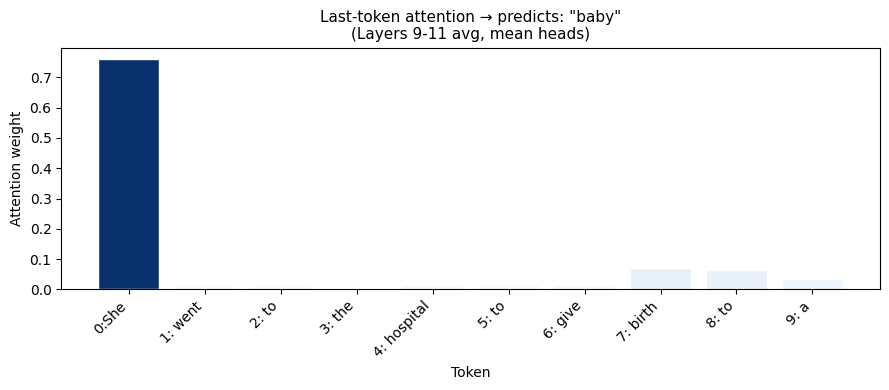


--- SINK MASKED (semantic signal) ---
Input          : She went to the hospital to give birth to a
Mode           : Layers 9-11 avg, mean heads | sink masked
Predicted next : "baby"
  (token 0 attention sink has been zeroed and weights re-normalised)
    Token  Attention Weight
      She          0.000000
     went          0.040234
       to          0.044873
      the          0.023815
 hospital          0.064573
       to          0.054813
     give          0.065863
    birth          0.296812
       to          0.265857
        a          0.143161

Top 5 attended tokens:
  1. " birth"  weight: 0.2968
  2. " to"  weight: 0.2659
  3. " a"  weight: 0.1432
  4. " give"  weight: 0.0659
  5. " hospital"  weight: 0.0646


/tmp/ipykernel_2177/2436995016.py:15: RuntimeWarning: invalid value encountered in divide
  return np.where(totals > 0, w / totals, w)


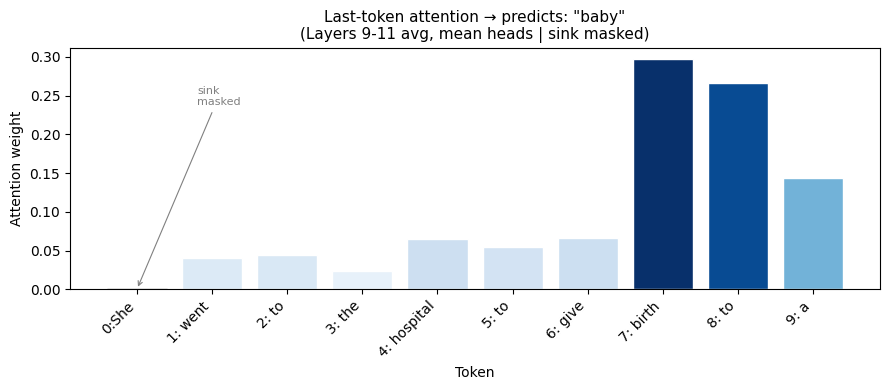

In [6]:
sentence = 'She went to the hospital to give birth to a'

print('\n--- RAW (sink visible) ---')
df_raw, _ = analyze_attention(sentence, mask_sink=False, show_heatmap=False)

print('\n--- SINK MASKED (semantic signal) ---')
df_clean, _ = analyze_attention(sentence, mask_sink=True, show_heatmap=False)

/tmp/ipykernel_2177/2436995016.py:15: RuntimeWarning: invalid value encountered in divide
  return np.where(totals > 0, w / totals, w)


Input          : The capital of France is
Mode           : Layers 9-11 avg, mean heads | sink masked
Predicted next : "the"
  (token 0 attention sink has been zeroed and weights re-normalised)
   Token  Attention Weight
     The          0.000000
 capital          0.251804
      of          0.122894
  France          0.407830
      is          0.217472

Top 5 attended tokens:
  1. " France"  weight: 0.4078
  2. " capital"  weight: 0.2518
  3. " is"  weight: 0.2175
  4. " of"  weight: 0.1229
  5. "The"  weight: 0.0000


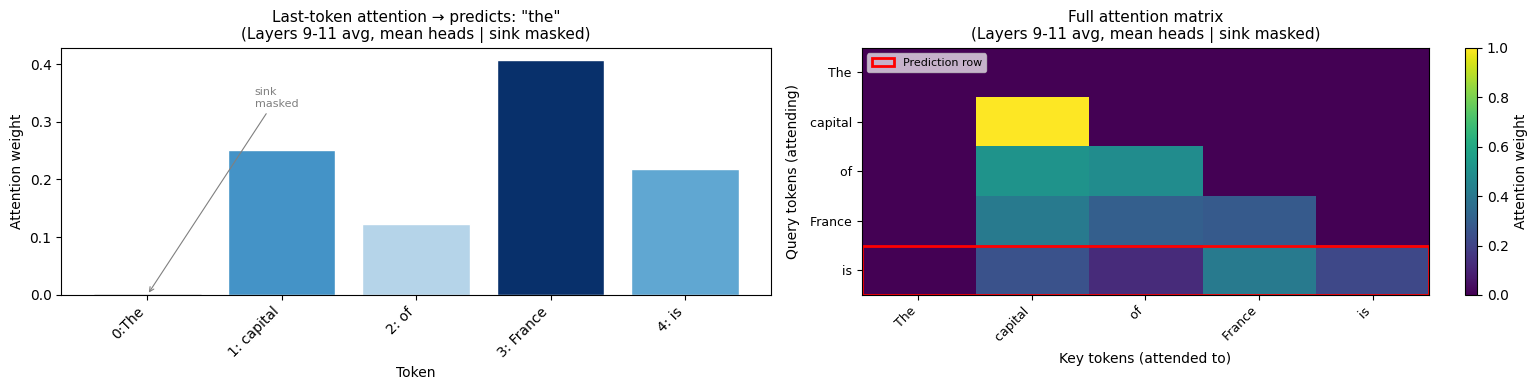

In [8]:
my_text = 'The capital of France is'   # <-- change me!
df2, word2 = analyze_attention(
    text=my_text,
    mode='late_layers',
    mask_sink=True,
    top_n=5
)

## Layer-by-layer comparison (with sink masking)

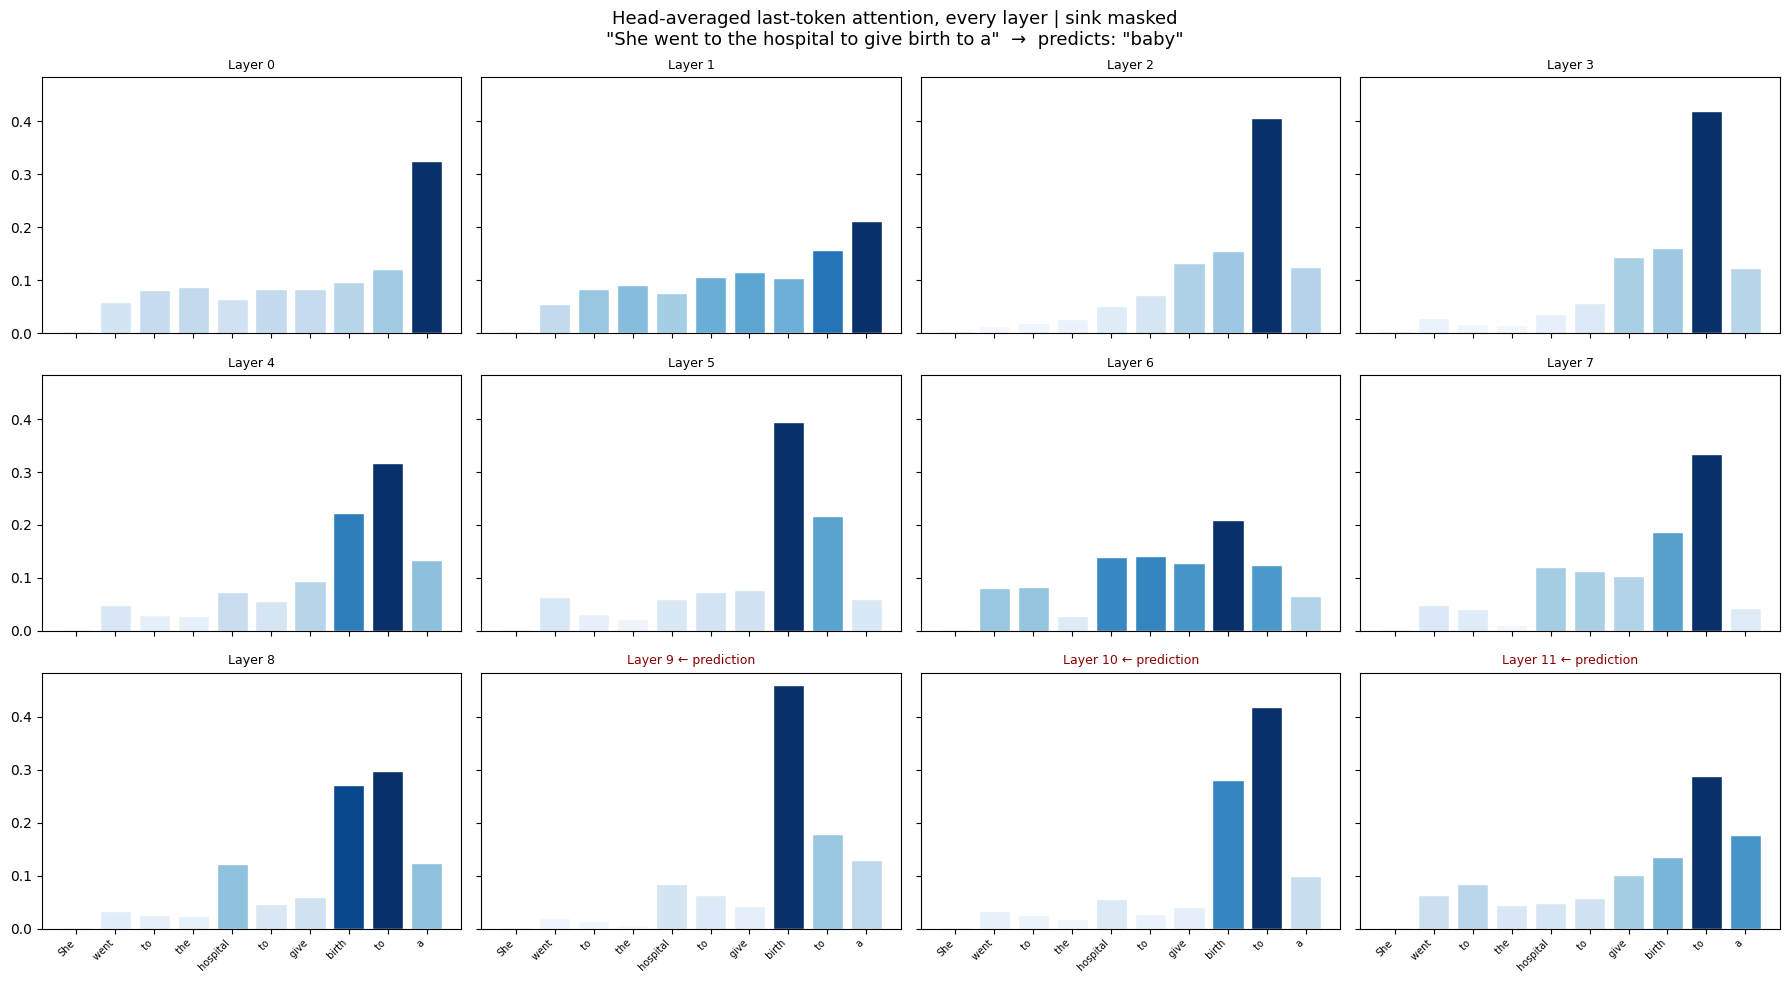

In [9]:
def layer_comparison(text, mask_sink_flag=True):
    """
    Head-averaged last-token attention for every layer, side-by-side.
    Layers 9-11 highlighted in red as most relevant for prediction.
    """
    input_ids = torch.tensor(tokenizer.encode(text)).unsqueeze(0)
    tokens    = [tokenizer.decode([t]) for t in input_ids[0].tolist()]

    with torch.no_grad():
        outputs = gpt2(
            input_ids=input_ids, output_attentions=True, return_dict=True
        )

    next_word = tokenizer.decode([outputs.logits[0, -1, :].argmax().item()]).strip()
    sink_label = ' | sink masked' if mask_sink_flag else ''

    fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True, sharey=True)
    fig.suptitle(
        f'Head-averaged last-token attention, every layer{sink_label}\n'
        f'"{text}"  →  predicts: "{next_word}"',
        fontsize=13
    )

    for l, ax in enumerate(axes.flat):
        row = outputs.attentions[l][0].mean(dim=0)[-1, :].detach().numpy()
        if mask_sink_flag:
            row = apply_sink_mask(row)
        colours = plt.cm.Blues(
            (row - row.min()) / (row.max() - row.min() + 1e-9)
        )
        bars = ax.bar(range(len(row)), row, color=colours, edgecolor='white')
        if mask_sink_flag:
            bars[0].set_color('lightgrey')
            bars[0].set_hatch('//')
        ax.set_title(
            f'Layer {l}' + (' ← prediction' if l >= 9 else ''),
            fontsize=9,
            color='darkred' if l >= 9 else 'black'
        )
        ax.set_xticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.show()


layer_comparison('She went to the hospital to give birth to a', mask_sink_flag=True)
